# Emirhan BULUT Voice Detection AI Software

In [2]:
#!unzip data_emir.zip

In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from IPython.display import display, Audio
DATASET_ROOT = os.path.join("C:/Users/DELL-L5410/AudioSig/Data/")
AUDIO_SUBFOLDER = "datas"
NOISE_SUBFOLDER = "noises"
DATASET_AUDIO_PATH = os.path.join(DATASET_ROOT, AUDIO_SUBFOLDER)
DATASET_NOISE_PATH = os.path.join(DATASET_ROOT, NOISE_SUBFOLDER)
VALID_SPLIT = 0.1
SHUFFLE_SEED = 36
SAMPLING_RATE = 16000
SCALE = 0.3
BATCH_SIZE = 128
EPOCHS = 20

In [2]:
temp = False

In [3]:
if temp:
    if os.path.exists(DATASET_AUDIO_PATH) is False:
        print("Hi")
        os.makedirs(DATASET_AUDIO_PATH)
    if os.path.exists(DATASET_NOISE_PATH) is False:
        print("Hi")
        os.makedirs(DATASET_NOISE_PATH)

In [4]:
if temp:
    for folder in os.listdir(DATASET_ROOT):
        #print("Hi")
        if os.path.isdir(os.path.join(DATASET_ROOT, folder)):
            print("Hi")
            if folder in [AUDIO_SUBFOLDER, NOISE_SUBFOLDER]:
                print("hi")
                continue
            elif folder in ["other", "_background_noise_"]:
                shutil.move(
                    os.path.join(DATASET_ROOT, folder),
                    os.path.join(DATASET_NOISE_PATH, folder),
                )
            else:
                shutil.move(
                    os.path.join(DATASET_ROOT, folder),
                    os.path.join(DATASET_AUDIO_PATH, folder),
                )

In [5]:
noise_paths = []
for subdir in os.listdir(DATASET_NOISE_PATH):
    subdir_path = Path(DATASET_NOISE_PATH) / subdir
    if os.path.isdir(subdir_path):
        noise_paths += [
            os.path.join(subdir_path, filepath)
            for filepath in os.listdir(subdir_path)
            if filepath.endswith(".wav")
        ]

print(
    "{} files found in {} directories {}".format(
        len(noise_paths), len(os.listdir(DATASET_NOISE_PATH)), os.listdir(DATASET_NOISE_PATH)
    )
)

6 files found in 2 directories ['other', '_background_noise_']


Resample all noise samples to 16000 Hz

In [6]:
command = (
    "for dir in `ls -1 " + DATASET_NOISE_PATH + "`; do "
    "for file in `ls -1 " + DATASET_NOISE_PATH + "/$dir/*.wav`; do "
    "sample_rate=`ffprobe -hide_banner -loglevel panic -show_streams "
    "$file | grep sample_rate | cut -f2 -d=`; "
    "if [ $sample_rate -ne 16000 ]; then "
    "ffmpeg -hide_banner -loglevel panic -y "
    "-i $file -ar 16000 temp.wav; "
    "mv temp.wav $file; "
    "fi; done; done"
)
os.system(command)

def load_noise_sample(path):
    sample, sampling_rate = tf.audio.decode_wav(
        tf.io.read_file(path), desired_channels=1
    )
    if sampling_rate == SAMPLING_RATE:
        slices = int(sample.shape[0] / SAMPLING_RATE)
        sample = tf.split(sample[: slices * SAMPLING_RATE], slices)
        return sample
    else:
        print("Sampling rate for {} is incorrect. Ignoring it".format(path))
        return None


noises = []
for path in noise_paths:
    sample = load_noise_sample(path)
    if sample:
        noises.extend(sample)
noises = tf.stack(noises)
print(
    "{} noise files were split into {} noise samples where each is {} sec. long".format(
        noises, noises.shape[0], noises.shape[1] // SAMPLING_RATE
    )
)

[[[ 0.        ]
  [ 0.        ]
  [ 0.        ]
  ...
  [-0.00695801]
  [ 0.00799561]
  [ 0.0350647 ]]

 [[ 0.02267456]
  [ 0.02301025]
  [ 0.03671265]
  ...
  [ 0.04626465]
  [ 0.01608276]
  [-0.00585938]]

 [[ 0.0272522 ]
  [ 0.00085449]
  [-0.02471924]
  ...
  [ 0.0274353 ]
  [ 0.00796509]
  [ 0.02160645]]

 ...

 [[-0.17391968]
  [-0.01364136]
  [ 0.01046753]
  ...
  [-0.0267334 ]
  [-0.08328247]
  [-0.05822754]]

 [[ 0.03665161]
  [ 0.01702881]
  [-0.05337524]
  ...
  [-0.1126709 ]
  [-0.06530762]
  [ 0.0892334 ]]

 [[-0.06396484]
  [ 0.03543091]
  [ 0.01025391]
  ...
  [ 0.00622559]
  [-0.07485962]
  [ 0.10687256]]] noise files were split into 354 noise samples where each is 1 sec. long


LOADING AUDIO PATHS

In [7]:
def paths_and_labels_to_dataset(audio_paths, labels):
    print(audio_paths)
    path_ds = tf.data.Dataset.from_tensor_slices(audio_paths)
    print("hi",type(path_ds))
    audio_ds = path_ds.map(lambda x: path_to_audio(x))
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    return tf.data.Dataset.zip((audio_ds, label_ds))


def path_to_audio(path):
    audio = tf.io.read_file(path)
    audio, _ = tf.audio.decode_wav(audio, 1, SAMPLING_RATE)
    return audio


def add_noise(audio, noises=None, scale=0.5):
    if noises is not None:
        tf_rnd = tf.random.uniform(
            (tf.shape(audio)[0],), 0, noises.shape[0], dtype=tf.int32
        )
        noise = tf.gather(noises, tf_rnd, axis=0)
        prop = tf.math.reduce_max(audio, axis=1) / tf.math.reduce_max(noise, axis=1)
        prop = tf.repeat(tf.expand_dims(prop, axis=1), tf.shape(audio)[1], axis=1)
        audio = audio + noise * prop * scale

    return audio


def audio_to_fft(audio):
    audio = tf.squeeze(audio, axis=-1)
    fft = tf.signal.fft(
        tf.cast(tf.complex(real=audio, imag=tf.zeros_like(audio)), tf.complex64)
    )
    fft = tf.expand_dims(fft, axis=-1)
    return tf.math.abs(fft[:, : (audio.shape[1] // 2), :])

class_names = os.listdir(DATASET_AUDIO_PATH)
print("Our class names: {}".format(class_names,))

audio_paths = []
labels = []
for label, name in enumerate(class_names):
    print("Processing voices {}".format(name,))
    dir_path = Path(DATASET_AUDIO_PATH) / name
    voice_sample_paths = [
        os.path.join(dir_path, filepath)
        for filepath in os.listdir(dir_path)
        if filepath.endswith(".wav")
    ]
    audio_paths += voice_sample_paths
    labels += [label] * len(voice_sample_paths)

print(
    "Found {} files belonging to {} classes.".format(len(audio_paths), len(class_names))
)

rng = np.random.RandomState(SHUFFLE_SEED)
rng.shuffle(audio_paths)
rng = np.random.RandomState(SHUFFLE_SEED)
rng.shuffle(labels)

num_val_samples = int(VALID_SPLIT * len(audio_paths))
print("Using {} files for training.".format(len(audio_paths) - num_val_samples))
train_audio_paths = audio_paths[:-num_val_samples]
train_labels = labels[:-num_val_samples]

print("Using {} files for validation.".format(num_val_samples))
valid_audio_paths = audio_paths[-num_val_samples:]
valid_labels = labels[-num_val_samples:]

train_ds = paths_and_labels_to_dataset(train_audio_paths, train_labels)
train_ds = train_ds.shuffle(buffer_size=BATCH_SIZE * 8, seed=SHUFFLE_SEED).batch(
    BATCH_SIZE
)

valid_ds = paths_and_labels_to_dataset(valid_audio_paths, valid_labels)
valid_ds = valid_ds.shuffle(buffer_size=32 * 8, seed=SHUFFLE_SEED).batch(32)

train_ds = train_ds.map(
    lambda x, y: (add_noise(x, noises, scale=SCALE), y),
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_ds = train_ds.map(
    lambda x, y: (audio_to_fft(x), y), num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

valid_ds = valid_ds.map(
    lambda x, y: (audio_to_fft(x), y), num_parallel_calls=tf.data.AUTOTUNE
)
valid_ds = valid_ds.prefetch(tf.data.AUTOTUNE)

Our class names: ['BackGroundMusic', 'VoiceSong']
Processing voices BackGroundMusic
Processing voices VoiceSong
Found 14 files belonging to 2 classes.
Using 13 files for training.
Using 1 files for validation.
['C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\VoiceSong\\2.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\VoiceSong\\3.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\VoiceSong\\4.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\4.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\1.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\5.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\7.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\8.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\VoiceSong\\5.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\VoiceSong\\1.wav', 'C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\2.wav', 'C:\\Users\\DELL-L5410\\Aud

In [9]:
def build_model(input_shape, num_classes):
    inputs = keras.layers.Input(shape=input_shape, name="input_name")

    x = keras.layers.Conv1D(16, 2)(inputs)
    x = keras.layers.MaxPool1D(pool_size=2, strides=2)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(32, activation="relu")(x)
    x = keras.layers.Dense(64, activation="relu")(x)

    outputs = keras.layers.Dense(num_classes, activation="sigmoid", name="output")(x)

    return keras.models.Model(inputs=inputs, outputs=outputs)


model = build_model((SAMPLING_RATE // 2, 1), len(class_names))

model.summary()

model.compile(
    optimizer="Adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model_save_filename = "VoiceDetect1.keras"

earlystopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
mdlcheckpoint_cb = keras.callbacks.ModelCheckpoint(
    model_save_filename, monitor="val_accuracy", save_best_only=True
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_name (InputLayer)              │ (None, 8000, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 7999, 16)            │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 3999, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 63984)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │       2,047,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,049,810 (7.82 MB)

 Trainable params: 2,049,810 (7.82 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=valid_ds,
    callbacks=[earlystopping_cb, mdlcheckpoint_cb],
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6154 - loss: 3.4121 - val_accuracy: 0.0000e+00 - val_loss: 0.7090
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step - accuracy: 0.3846 - loss: 76.8022 - val_accuracy: 1.0000 - val_loss: 0.6232
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8462 - loss: 0.2174 - val_accuracy: 1.0000 - val_loss: 0.4820
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6154 - loss: 33.1077 - val_accuracy: 1.0000 - val_loss: 0.3227
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.6154 - loss: 10.9495 - val_accuracy: 1.0000 - val_loss: 0.1931
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8462 - loss: 0.5306 - val_accuracy: 1.0000 - val_loss: 0.1137
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6154 - loss: 2.8245 - val_accuracy: 1.0000 - val_loss: 0.0617
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8462 - loss: 1.1708 - val_accuracy: 1.0000 - val_l

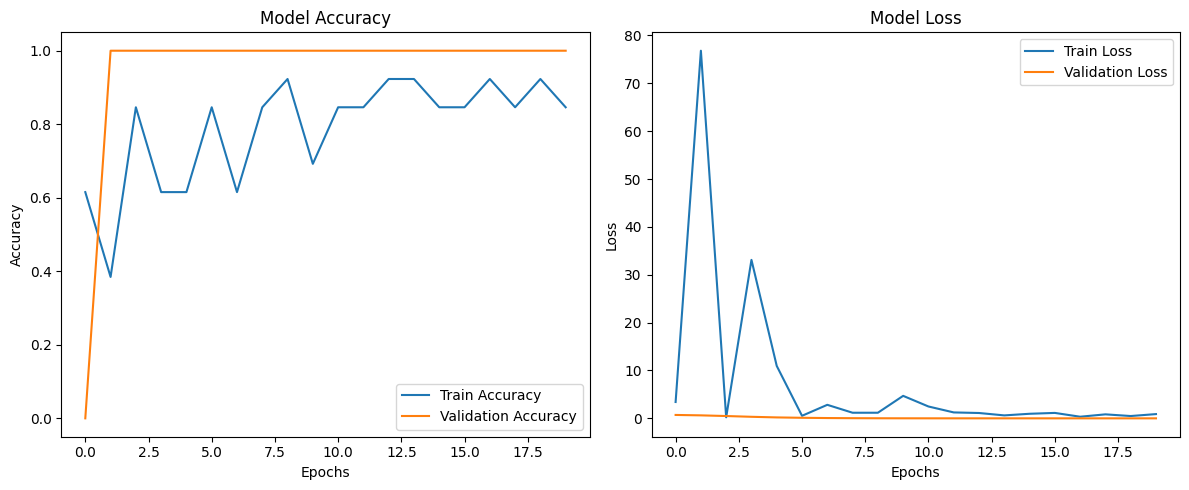

In [15]:
plot_history(history)

In [9]:
model.save("songDetect.keras")

In [24]:
print(model.evaluate(valid_ds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 1.5736e-05
[1.5735502529423684e-05, 1.0]


In [29]:
loss, accuracy = model.evaluate(valid_ds)

print(loss)
print(accuracy - 0.02)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 1.5736e-05
1.5735502529423684e-05
0.98


In [11]:
display_example = 1

test_ds = paths_and_labels_to_dataset(valid_audio_paths, valid_labels)
test_ds = test_ds.shuffle(buffer_size=BATCH_SIZE * 8, seed=SHUFFLE_SEED).batch(
    BATCH_SIZE
)

test_ds = test_ds.map(lambda x, y: (add_noise(x, noises, scale=SCALE), y))
print(test_ds)
for audios, labels in test_ds.take(1):
    ffts = audio_to_fft(audios)
    y_pred = model.predict(ffts)
    rnd = np.random.randint(0, 1, display_example)
    audios = audios.numpy()[rnd, :, :]
    labels = labels.numpy()[rnd]
    y_pred = np.argmax(y_pred, axis=-1)[rnd]

    for index in range(display_example):
        print(labels[index])
        print(
            "Voice Type:\33{} {}\33[0m\tPredicted:\33{} {}\33[0m".format(
                "[92m" if labels[index] == y_pred[index] else "[91m",
                class_names[labels[index]],
                "[92m" if labels[index] == y_pred[index] else "[91m",
                class_names[y_pred[index]],
            )
        )
        display(Audio(audios[index, :, :].squeeze(), rate=SAMPLING_RATE))

['C:\\Users\\DELL-L5410\\AudioSig\\Data\\datas\\BackGroundMusic\\6.wav']
hi <class 'tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset'>
<_MapDataset element_spec=(TensorSpec(shape=(None, 16000, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
0
Voice Type: BackGroundMusic	Predicted: BackGroundMusic


In [21]:
import joblib
joblib.dump(labels, 'labels')
joblib.dump(noises,'noises')
joblib.dump(class_names,'class_names')
joblib.dump(accuracy,'Accuracy')

['Accuracy']

In [17]:
print(class_names)

['BackGroundMusic', 'VoiceSong']


In [16]:
import matplotlib.pyplot as plt
def plot_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='best')

    plt.tight_layout()
    plt.show()
